<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment2/blob/main/ESAA_OB_WEEK1_study_0831.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#8. 텍스트 분석

###NLP냐 텍스트 분석이냐?
- NLP는 인간의 언어를 이해·해석하는 데, 텍스트 분석은 비정형 텍스트에서 의미 있는 정보를 추출하는 데 중점을 둠.
- NLP는 기계 번역·질의응답 등 언어 이해를 담당하며, 텍스트 분석을 발전시키는 기반 기술로 볼 수 있음.
- 머신러닝을 활용하면서 룰 기반 분석에서 데이터 기반 예측·정보 추출 방식으로 발전했으며, 비즈니스 인텔리전스와 예측 분석 등에 활용됨.
- 텍스트 분석의 기술
  - **텍스트 분류**는 문서를 특정 카테고리로 자동 분류하는 기법으로, 주로 지도학습을 활용함.
  - **감성 분석**은 텍스트의 감정·의견 등을 분석하는 기법이며, 지도학습과 비지도학습 모두 활용 가능함.
  - **텍스트 요약**은 핵심 내용을 추출하고, **텍스트 군집화·유사도 측정**은 비슷한 문서끼리 묶거나 문서 간 유사성을 측정하는 기법임.

##8.1 텍스트 분석의 이해

- 텍스트 분석은 비정형 텍스트 데이터를 머신러닝으로 분석하는 과정임.
- 머신러닝에 텍스트를 적용하려면 단어를 피처로 추출하고 숫자 값을 부여해 벡터 형태로 변환해야 함.
- 이를 피처 벡터화 또는 피처 추출이라 하며, 대표적인 방법으로 BOW와 Word2Vec이 있음.

###텍스트 분석 수행 프로세스
- **텍스트 전처리** 단계에서 클렌징, 토큰화, 불용어 제거, 어근 추출 등을 통해 텍스트를 정규화함.
- 전처리된 텍스트에서 **피처를 추출하고 벡터값을 부여**하며, 대표적으로 BOW와 Word2Vec을 사용함.
- 벡터화된 데이터를 **머신러닝 모델에 적용해 학습·예측하고 성능을 평가**함.
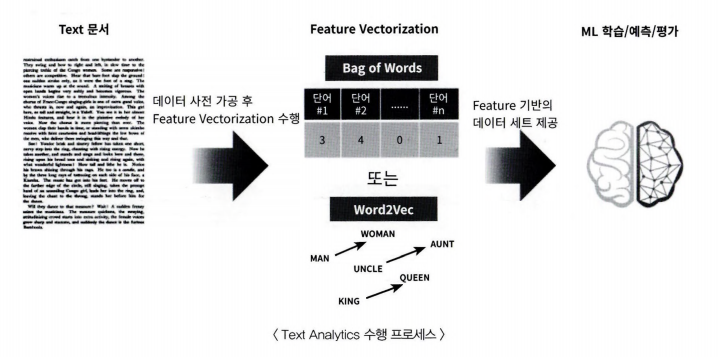

###파이썬 기반의 NLP, 텍스트 분석 패키지
- **NLTK**는 다양한 데이터와 기능을 제공하는 대표적인 NLP 패키지지만, 대용량 데이터 처리 성능에는 한계가 있음.
- **Gensim**은 토픽 모델링과 Word2Vec에 강점이 있으며, **SpaCy**는 뛰어난 처리 성능으로 실무에서 많이 활용됨.
- **사이킷런**은 텍스트 전용 기능은 부족하지만 피처 벡터화와 머신러닝 모델 적용이 편리해 NLP 패키지와 함께 사용됨.

##8.2 텍스트 사전 준비 작업(텍스트 전처리) - 텍스트 정규화
- 텍스트를 머신러닝 알고리즘이나 NLP 애플리케이션에 입력 데이터로 사용하기 위해 텍스트 데이터의 사전 작업을 수행하는 것

###클렌징(Cleansing)
- 텍스트에서 분석에 오히려 방해가 되는 불필요한 문자, 기호 등을 사전에 제거하는 작업

###토큰화(Tokenization)
####문장 토큰화
- 마침표나 개행문자 등 문장의 끝을 나타내는 기호를 기준으로 문장을 분리하는 작업임.
- NLTK에서는 sent_tokenize()를 사용해 문장 단위로 쉽게 토큰화할 수 있음.
- sent_tokenize()는 분리된 문장들을 리스트 형태로 반환하며, 최초 사용 시 필요한 데이터셋을 다운로드해야 함.

In [ ]:
import nltk
from nltk import sent_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

text_sample = 'The Matrix is everywhere its all around us, here even in this room. \
You can see it out your window or on your television. \
You feel it when you go to work, or go to church or pay our taxes.'

sentences = sent_tokenize(text = text_sample)

print(type(sentences), len(sentences))
print(sentences)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


<class 'list'> 3
['The Matrix is everywhere its all around us, here even in this room.', 'You can see it out your window or on your television.', 'You feel it when you go to work, or go to church or pay our taxes.']


####단어 토큰화
- 문장을 공백, 쉼표, 마침표, 개행문자 등을 기준으로 개별 단어로 분리하는 작업임.
- 정규 표현식을 활용하면 다양한 기준으로 단어를 토큰화할 수 있으며, BOW처럼 단어 순서가 중요하지 않은 경우 단어 토큰화만으로 충분함.
- 문장 토큰화는 문장 자체의 의미가 중요한 경우 사용하며, NLTK에서는 word_tokenize()를 제공함.

In [ ]:
from nltk import word_tokenize

sentence = "The Matrix is everywhere its all around us, here even in this room."
words = word_tokenize(sentence)
print(type(words), len(words))
print(words)

<class 'list'> 15
['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.']


In [ ]:
from nltk import word_tokenize, sent_tokenize

# 여러 개의 문장으로 된 입력 데이터를 문장별로 단어 토큰화하게 만드는 함수 생성
def tokenize_text(text):

  # 문장별로 분리 토큰
  sentences = sent_tokenize(text)
  # 분리된 문장별 단어 토큰화
  word_tokens = [word_tokenize(sentence) for sentence in sentences]
  return word_tokens

# 여러 문장에 대해 문장별 단어 토큰화 수행.
word_tokens = tokenize_text(text_sample)
print(type(word_tokens), len(word_tokens))
print(word_tokens)

<class 'list'> 3
[['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.'], ['You', 'can', 'see', 'it', 'out', 'your', 'window', 'or', 'on', 'your', 'television', '.'], ['You', 'feel', 'it', 'when', 'you', 'go', 'to', 'work', ',', 'or', 'go', 'to', 'church', 'or', 'pay', 'our', 'taxes', '.']]


- 문장별 단어 토큰화 결과는 3개의 리스트를 포함하는 리스트 형태로 저장되며, 각 리스트에는 해당 문장의 단어들이 포함됨.
- 단어를 개별적으로 토큰화하면 단어 간 문맥과 의미가 무시될 수 있어 이를 보완하기 위해 n-gram을 사용함.
- n-gram은 연속된 n개의 단어를 하나의 토큰으로 묶는 방식이며, 예를 들어 bigram은 2개 단어씩 묶어 토큰화함.

###스톱 워드 제거
- 스톱 워드: 문법적으로 필요하지만 분석에는 큰 의미가 없는 단어
  - is, the, a, will
- 텍스트 분석 시 스톱 워드를 사전에 제거하는 것이 중요한 전처리 과정임.

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
print('영어 stop words 개수:', len(nltk.corpus.stopwords.words('english')))
print(nltk.corpus.stopwords.words('english')[:20])

영어 stop words 개수: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [ ]:
import nltk

stopwords = nltk.corpus.stopwords.words('english')
all_tokens = []
# 위 예제에서 3개의 문장별로 얻은 word_tokens list에 대해 스톱 워드를 제거하는 반복문
for sentence in word_tokens:
  filtered_words=[]
  # 개별 문장별로 토큰화된 문장 list에 대해 스톱 워드를 제거하는 반복문
  for word in sentence:
    # 소문자로 모두 변환합니다.
    word = word.lower()
    # 토큰화된 개별 단어가 스톱 워드의 단어에 포함되지 않으면 word_tokens에 추가
    if word not in stopwords:
      filtered_words.append(word)
  all_tokens.append(filtered_words)

print(all_tokens)

[['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', '.'], ['see', 'window', 'television', '.'], ['feel', 'go', 'work', ',', 'go', 'church', 'pay', 'taxes', '.']]


###Stemming과 Lemmatization
- Stemming과 Lemmatization은 형태가 변한 단어에서 원형을 찾는 전처리 기법이며, Lemmatization이 더 정교함.
- Stemming은 단순한 규칙으로 어근을 추출해 철자가 훼손될 수 있지만, Lemmatization은 품사와 의미를 고려해 정확한 원형을 찾음.
- NLTK에서는 Porter·Lancaster·Snowball Stemmer와 WordNetLemmatizer를 제공하며, Stemming은 stem() 메서드로 수행함.

In [ ]:
#Stemming
from nltk.stem import LancasterStemmer
stemmer = LancasterStemmer()

print(stemmer.stem('working'), stemmer.stem('works'), stemmer.stem('worked'))
print(stemmer.stem('amusing'), stemmer.stem('amuses'), stemmer.stem('amused'))
print(stemmer.stem('happier'), stemmer.stem('happiest'))
print(stemmer.stem('fancier'), stemmer.stem('fanciest'))

work work work
amus amus amus
happy happiest
fant fanciest


In [ ]:
#Lemmatization
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

lemma = WordNetLemmatizer()
print(lemma.lemmatize('amusing', 'v'), lemma.lemmatize('amuses', 'v'), lemma.lemmatize('amused', 'v'))
print(lemma.lemmatize('happier', 'a'), lemma.lemmatize('happiest', 'a'))
print(lemma.lemmatize('fancier', 'a'), lemma.lemmatize('fanciest', 'a'))

[nltk_data] Downloading package wordnet to /root/nltk_data...


amuse amuse amuse
happy happy
fancy fancy


##8.3 Bag of Words - BOW

- 문서가 가지는 모든 단어(Words)를 문맥이나 순서를 무시하고 일괄적으로 단어에 대해 빈도 값을 부여해 피처 값을 추출하는 모델
  - 두 문장에 등장하는 모든 단어의 중복을 제거해 피처(단어)를 만들고, 각 단어에 고유한 인덱스를 부여함.
  - 각 문장에서 단어가 등장한 횟수를 세어 해당 단어의 피처 값으로 기록함.
  - 이렇게 문서를 단어와 등장 횟수 기반의 벡터로 표현하는 방식이 BOW의 Count 기반 피처 벡터화임.

- 장단점
  - BOW는 단어의 등장 횟수를 기반으로 해 구축이 쉽고 빠르며, 문서의 특징을 비교적 잘 표현할 수 있음.
  - 단어 순서를 고려하지 않아 문맥적 의미를 반영하기 어렵고, n-gram으로 보완할 수 있지만 한계가 있음.
  - 많은 단어를 피처로 사용하면 대부분 값이 0인 희소 행렬이 생성되어 머신러닝의 처리 시간과 예측 성능에 악영향을 줄 수 있음.

###Bow 피처 벡터화
- 머신러닝은 숫자형 피처를 입력받기 때문에 **텍스트를 의미 있는 숫자 벡터로 변환**하는 피처 벡터화가 필요함.
- BOW에서는 모든 문서의 단어를 피처로 만들고, **각 문서에서 단어의 등장 횟수나 정규화된 빈도**를 값으로 부여함.
- M개의 문서에서 N개의 단어를 추출하면 각 문서를 N차원 벡터로 표현해 최종적으로 **M×N 크기의 행렬**을 구성함.
- BOW 피처 벡터화는 **카운트 기반**과 **TF-IDF 기반** 방식으로 나뉨.
  - 카운트 기반은 **단어의 등장 횟수가 많을수록 중요하게 평가**하지만, 흔하게 사용되는 단어도 중요도가 높아지는 한계가 있음.
   - TF-IDF는 특정 문서에서 자주 등장하는 단어에는 높은 **가중치**를, 모든 문서에서 자주 등장하는 단어에는 **페널티**를 부여해 문서의 특징을 더 잘 나타냄.

###사이킷런의 Count 및 TF-IDF 벡터화 구현: CountVectorizer, TfidfVectorizer

####CountVectorizer
- 단어의 등장 횟수를 기반으로 벡터화하며, 소문자 변환·토큰화·스톱 워드 제거 등의 전처리도 함께 수행함.
- 입력 파라미터
  - max_df, min_df, max_features로 불필요하거나 빈도가 낮은 단어와 피처 수를 제한하고, stop_words, n_gram_range로 스톱 워드 제거와 단어 순서 반영 범위를 설정함.
  - analyzer, token_pattern, tokenizer로 피처 추출 단위와 토큰화 방식을 조정하며, fit()과 transform()을 통해 벡터화를 수행함.
- CountVectorizer는 소문자 변환, 토큰화, 스톱 워드 제거 등의 전처리 후 단어를 피처로 추출하고 빈도수 기반 벡터를 생성함.
- Stemming·Lemmatization은 직접 지원하지 않지만 tokenizer에 커스텀 함수를 적용해 어근 변환이 가능하며, max_df, min_df, max_features로 피처를 조정함.
####TF-IDF 벡터화
- TfidfVectorizer 클래스를 사용하며, 기본적인 파라미터와 변환 방식은 CountVectorizer와 동일함.

###Bow 벡터화를 위한 희소 행렬
- CountVectorizer와 TfidfVectorizer는 텍스트를 벡터화해 대부분의 **값이 0인 CSR 형태의 희소 행렬**을 반환함.
- BOW는 수만~수십만 개의 피처가 생성될 수 있지만 각 문서에 포함된 단어는 일부에 불과해 대부분 0으로 채워지는 희소 행렬이 됨.
- 희소 행렬은 메모리와 연산 효율을 높이기 위해 **COO·CSR 방식**으로 저장하며, 일반적으로 저장 및 계산 효율이 좋은 **CSR 형식**을 많이 사용함.

####COO 형식
- COO 형식은 0이 아닌 값만 데이터 배열에 저장하고, 해당 값의 행(row)과 열(column) 위치를 별도 배열에 저장함.
- 예를 들어 [[3, 0, 1], [0, 2, 0]]은 데이터 [3, 1, 2], 행 [0, 0, 1], 열 [0, 2, 1]로 표현됨.
- 파이썬에서는 주로 SciPy의 sparse 패키지를 이용해 희소 행렬을 COO 형식으로 변환함.

In [ ]:
import numpy as np

dense = np.array([[3,0,1], [0,2,0]])

In [ ]:
from scipy import sparse

# 0이 아닌 데이터 추출
data = np.array([3,1,2])

# 행 위치와 열 위치를 각각 배열로 생성
row_pos = np.array([0,0,1])
col_pos = np.array([0,2,1])

# sparse 패키지의 coo_matrix를 이용해 COO 형식으로 희소 행렬 생성
sparse_coo = sparse.coo_matrix((data,(row_pos, col_pos)))

In [ ]:
sparse_coo.toarray()

array([[3, 0, 1],
       [0, 2, 0]])

####CSR 형식
- COO 형식이 행과 열의 위치를 나타내기 위해서 반복적인
위치 데이터를 사용해야 하는 문제점을 해결한 방식

In [ ]:
[ [0, 0, 1, 0, 0, 5], [1, 4, 0, 3, 2, 5], [0, 6, 0, 3, 0, 0], [2, 0, 0, 0, 0,0], [0, 0, 0, 7, 0,
8], [1, 0, 0, 0, 0, 0] ]

[[0, 0, 1, 0, 0, 5],
 [1, 4, 0, 3, 2, 5],
 [0, 6, 0, 3, 0, 0],
 [2, 0, 0, 0, 0, 0],
 [0, 0, 0, 7, 0, 8],
 [1, 0, 0, 0, 0, 0]]

- CSR은 COO의 반복되는 행 위치 정보를 줄이기 위해 각 행의 시작 위치만 저장하는 방식임.
- 행 위치 배열 [0,0,1,1,1,1,1,2,2,3,4,4,5]를 CSR로 압축하면 [0,2,7,9,10,12,13]으로 표현됨.
- 반복 정보를 제거해 COO보다 메모리를 적게 사용하고 연산 속도가 빠르며, 저장된 위치 정보로 원래 행 구조를 복원할 수 있음.

In [ ]:
import numpy as np
from scipy import sparse

dense2 = np.array([[0, 0, 1, 0, 0, 5],
                   [1, 4, 0, 3, 2, 5],
                   [0, 6, 0, 3, 0, 0],
                   [2, 0, 0, 0, 0, 0],
                   [0, 0, 0, 7, 0, 8],
                   [1, 0, 0, 0, 0, 0]])

# 0이 아닌 데이터 추출
data2 = np.array([1, 5, 1, 4, 3, 2, 5, 6, 3, 2, 7, 8, 1])

# 행 위치와 열 위치를 각각 array로 생성
row_pos = np.array([0, 0, 1, 1, 1, 1, 1, 2, 2, 3, 4, 4, 5])
col_pos = np.array([2, 5, 0, 1, 3, 4, 5, 1, 3, 0, 3, 5, 0])

# COO 형식으로 변환
sparse_coo = sparse.coo_matrix((data2, (row_pos, col_pos)))

# 행 위치 배열의 고유한 값의 시작 위치 인덱스를 배열로 생성
row_pos_ind = np.array([0, 2, 7, 9, 10, 12, 13])

# CSR 형식으로 변환
sparse_csr = sparse.csr_matrix((data2, col_pos, row_pos_ind))

print('COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_coo.toarray())
print('CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_csr.toarray())

COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]
CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]


In [ ]:
# 밀집 행렬을 생성 파라미터로 입력하면 희소행렬로 생성
dense3 = np.array([[0, 0, 1, 0, 0, 5],
                   [1, 4, 0, 3, 2, 5],
                   [0, 6, 0, 3, 0, 0],
                   [2, 0, 0, 0, 0, 0],
                   [0, 0, 0, 7, 0, 8],
                   [1, 0, 0, 0, 0, 0]])

coo = sparse.coo_matrix(dense3)
csr = sparse.csr_matrix(dense3)